In [1]:
from env import (
    MultiLeafThreadEnv,
    ThreadingConfig,
)
import torch
import random
from viz import draw_local_tree_sequence, draw_tree_edge_index
from utils import _timed_tree_to_graph_full
import matplotlib.pyplot as plt

from utils import build_backbone_segments_from_reference
from viz import draw_local_tree_sequence

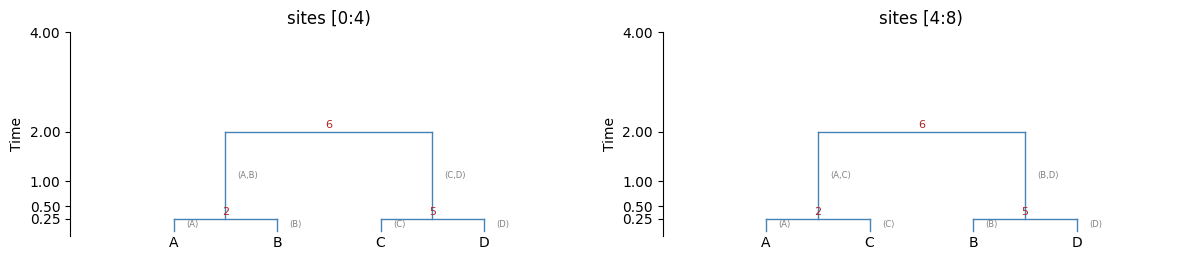

In [2]:
## First example
REFERENCE_FULL_TREES = [
    {
        "sites": (0, 4),
        # "tree": ("n", 2.0, ("n", 1.0, ("n", 1.0, 0, 1), 2), 3),
        "tree": ("n", 2.0, ("n", 0.25, 0, 1), ("n", 0.25, 2, 3)),
    },
    {
        "sites": (4, 8),
        "tree": ("n", 2.0, ("n", 0.25, 0, 2), ("n", 0.25, 1, 3)),
    },
]

GENO = torch.tensor(
    [
        [0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 1, 1, 1, 1],
        [1, 1, 1, 1, 0, 0, 0, 0],
        [1, 1, 1, 1, 1, 1, 1, 1],
    ],
    dtype=torch.long,
)
LEAF_NAMES = ["A", "B", "C", "D"]
ALL_LEAF_IDS = [0, 1, 2, 3]
TIME_GRID = (0.25, 0.5, 1.0, 2.0, 4.0)


## View this tree. 

full_tree_backbone = build_backbone_segments_from_reference(REFERENCE_FULL_TREES, focal_leaf=-1)
draw_local_tree_sequence(full_tree_backbone, leaf_names=LEAF_NAMES, time_grid=TIME_GRID, use_time_as_y=True)


In [3]:
multi_env_cfg = ThreadingConfig.from_raw(GENO, TIME_GRID, 0.4, 0.35, 0.15)
env = MultiLeafThreadEnv(multi_env_cfg, ALL_LEAF_IDS, REFERENCE_FULL_TREES)

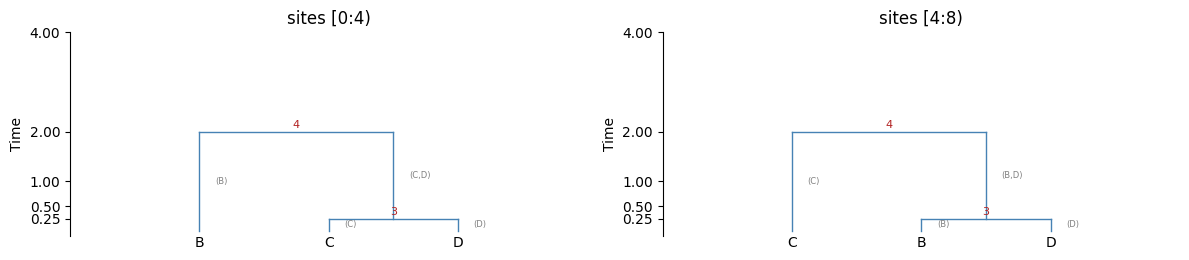

In [4]:
## Threading Process of Sample A. 
env.reset() ## Initial state. removes first sample in the orderfrom the backbone
draw_local_tree_sequence(env._inner_env.backbone_segments, leaf_names=LEAF_NAMES, time_grid=TIME_GRID, use_time_as_y=True)


[leaf A] site 0 -> branch (B) @ t0=0.25 [start]


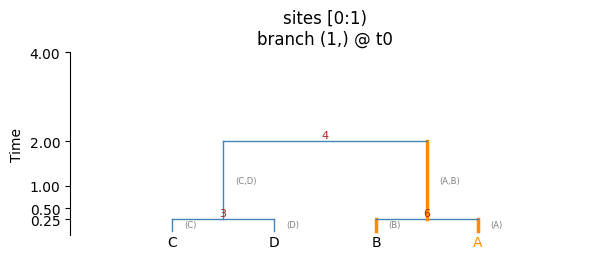

[leaf A] site 0 -> branch (B) @ t1=0.50 [start]


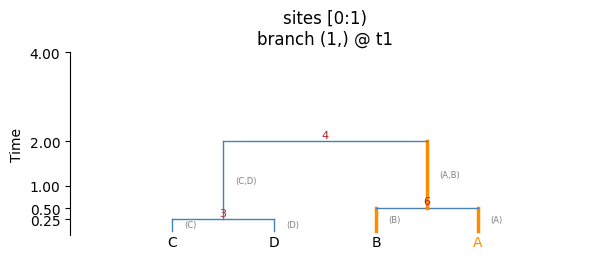

[leaf A] site 0 -> branch (B) @ t2=1.00 [start]


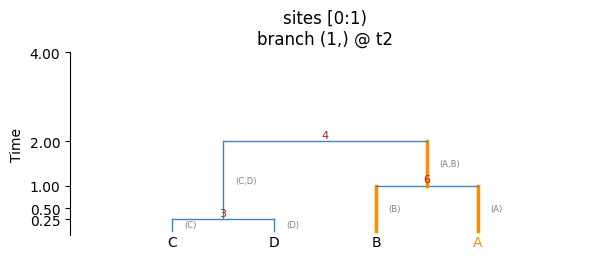

[leaf A] site 0 -> branch (B) @ t3=2.00 [start]


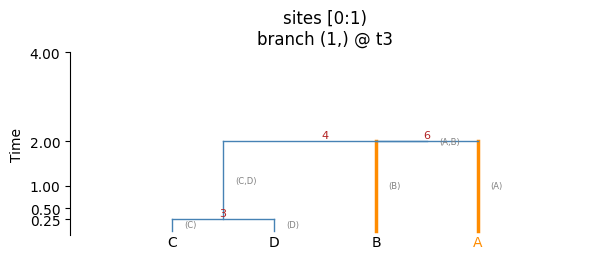

[leaf A] site 0 -> branch (C) @ t0=0.25 [start]


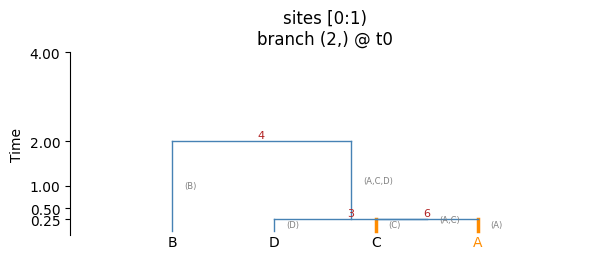

[leaf A] site 0 -> branch (C,D) @ t1=0.50 [start]


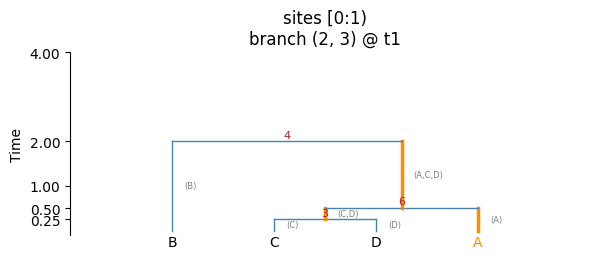

[leaf A] site 0 -> branch (C,D) @ t2=1.00 [start]


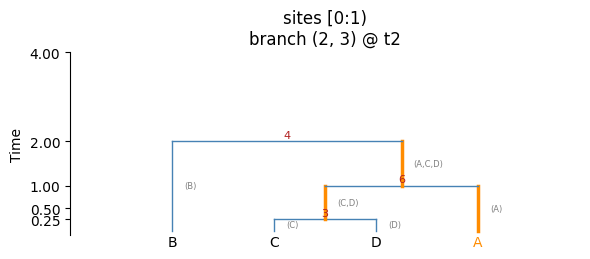

[leaf A] site 0 -> branch root @ t4=4.00 [start]


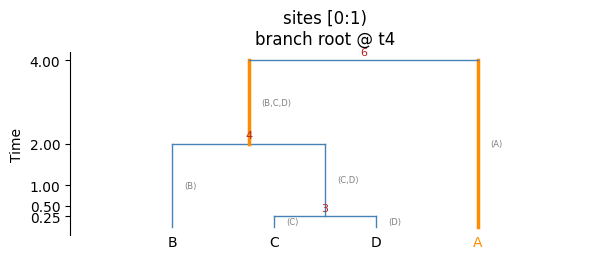

In [7]:
## Possible Actions space for single Site
st = env.reset()
valid_acts = env.valid_actions(st)
for i in range(len(valid_acts)):
    st = env.reset()
    k = env.describe_action(st, valid_acts[i], leaf_names=LEAF_NAMES)
    print(k)
    
    valid_acts = env.valid_actions(st)

    choice = env._inner_env.site_choices[st.inner_state.site_index][valid_acts[i]]
    # print(choice.branch_signature, choice.time_value)

    st, reward, done = env.step(st, valid_acts[i])
    # Get the local trees with the focal leaf threaded in

    local_trees = env._inner_env.snapshot_state(st.inner_state)

    # Visualize as a tree sequence
    draw_local_tree_sequence(local_trees, leaf_names=["A", "B", "C", "D"], time_grid=TIME_GRID, use_time_as_y=True)